In [1]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1

import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)
filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Excitation 1s5 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). Measurements of 

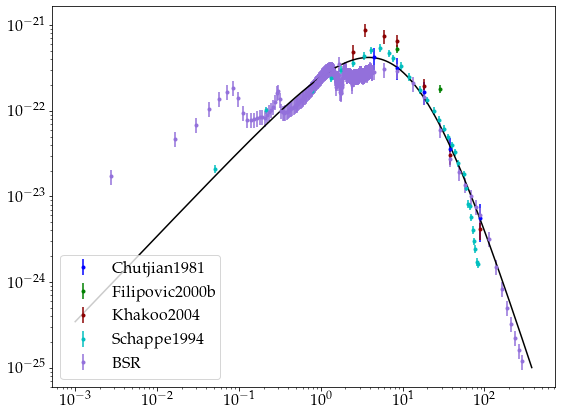

In [73]:
from models import *
level = 1
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
    
theta_ref = np.array([51.2e0,2.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


[106.14268728   2.13882303]


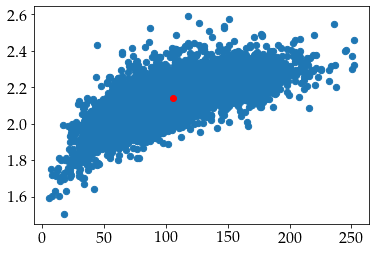

In [74]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s5.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

mean_1s5 = np.mean(flat_samples[:,:2], axis=0)
print(mean_1s5)

plt.figure(1)
plt.scatter(flat_samples[:,0], flat_samples[:,1],s=40.0)
plt.plot(mean_1s5[0], mean_1s5[1], 'or')

6496


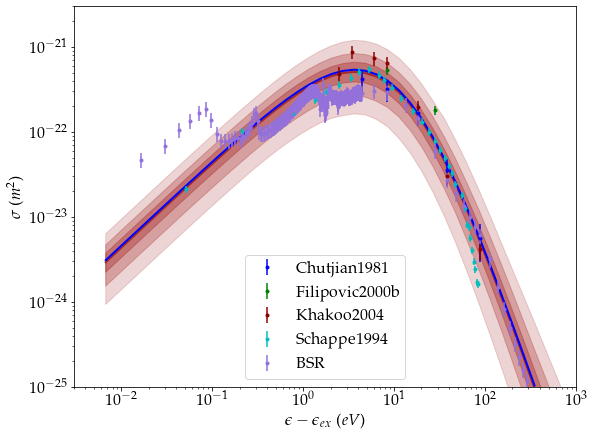

In [75]:
Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
    modelSamples[k] = Excite_metastable(level,sample[:2],Etest)
#     models = Excite_resonance_modified(level,sample[:2],Etest)
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest - E_ext[level-1], modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

nominal = Excite_metastable(level,mean_1s5,Etest)
mask = nominal > 1.0e-25
plt.plot(Etest[mask]-E_ext[level-1], nominal[mask], "b-", linewidth=2.0)

for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s5.curve.pdf", dpi=1200)

filename = '../crs-Bayes-gpr/without-swarm/post-process/excitation.1s5.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

## Excitation 1s3 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). Measurements of 

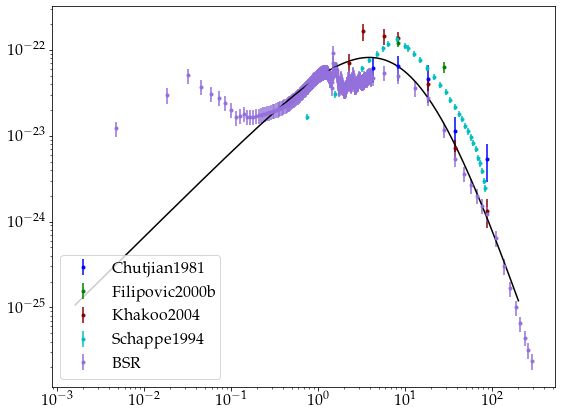

In [76]:
from models import *
level = 3
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
        filename = '%s.1s%d.txt' % (refs[k], 6-level)
        np.savetxt(filename, temp)
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
        
        filename = '%s.1s%d.txt' % ('BSR', 6-level)
        np.savetxt(filename, temp)

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([10.4e0,2.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)

temp = np.append(Etest[...,None], model0[...,None], axis=1)
filename = '%s.1s%d.model.txt' % ('Bretagne', 6-level)
np.savetxt(filename, temp)

mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


[15.73364769  1.96004018]


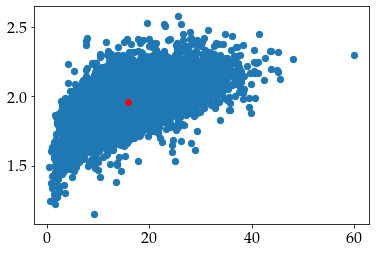

In [77]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

mean_1s3 = np.mean(flat_samples[:,:2], axis=0)
print(mean_1s3)

plt.figure(1)
plt.scatter(flat_samples[:,0], flat_samples[:,1],s=40.0)
plt.plot(mean_1s3[0], mean_1s3[1], 'or')

6208


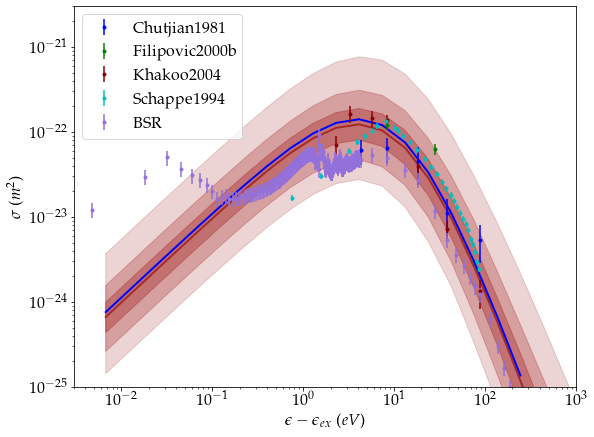

In [78]:
Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
    modelSamples[k] = Excite_metastable(level,sample[:2],Etest)
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest - E_ext[level-1], modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

nominal = Excite_metastable(level,mean_1s3,Etest)
mask = nominal > 1.0e-25
plt.plot(Etest[mask]-E_ext[level-1], nominal[mask], "b-", linewidth=2.0)
    
for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.pdf", dpi=1200)

filename = '../crs-Bayes-gpr/without-swarm/post-process/excitation.1s3.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

## Excitation 1s4 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & 

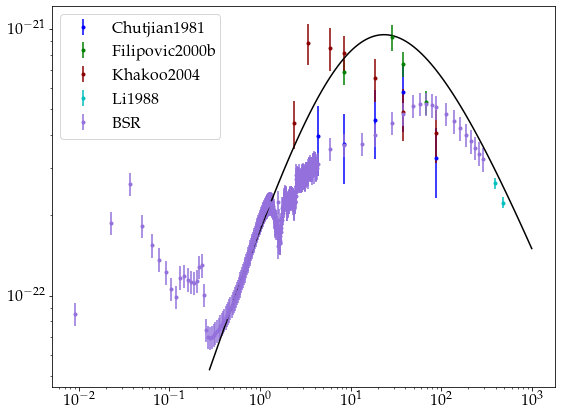

In [79]:
from models import *
level = 2
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([0.61e-1,0.5])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_resonance_modified(level,theta_ref,Etest)
# model0 = Excite_resonance(4,theta_ref,Etest)
mask = model0 > 5.0e-23
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="upper left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


[0.0801364 0.9461873]


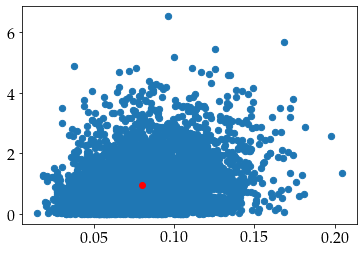

In [80]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s4.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

mean_1s4 = np.mean(flat_samples[:,:2], axis=0)
print(mean_1s4)

plt.figure(1)
plt.scatter(flat_samples[:,0], flat_samples[:,1],s=40.0)
plt.plot(mean_1s4[0], mean_1s4[1], 'or')

4800


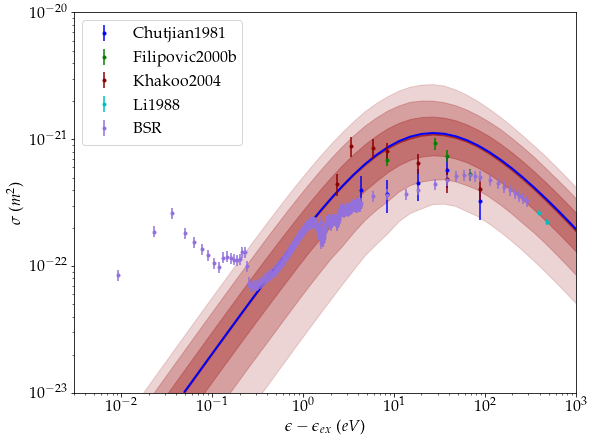

In [81]:
Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
    modelSamples[k] = Excite_resonance_modified(level,sample[:2],Etest)
#     mask = models > 1.0e-23
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest - E_ext[level-1], modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

nominal = Excite_resonance_modified(level,mean_1s4,Etest)
mask = nominal > 1.0e-23
plt.plot(Etest[mask]-E_ext[level-1], nominal[mask], "b-", linewidth=2.0)

for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s4.curve.pdf", dpi=1200)

filename = '../crs-Bayes-gpr/without-swarm/post-process/excitation.1s4.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

## Excitation 1s2 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
16.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
14.0
Li, G. P., Takayanagi, T., Wakiya, K., Suzuki, H., Ajiro, T., Yagi, S., Kano, S. S., & Takuma, H. (1988). Determination of cross sections and oscillator strengths for argon by electron-energy-loss spectroscopy. Physical Review A, 38(3), 1240–1247. https://doi.org/10.1103/PhysRevA.38.1240
396.8786575783061
11.828
98


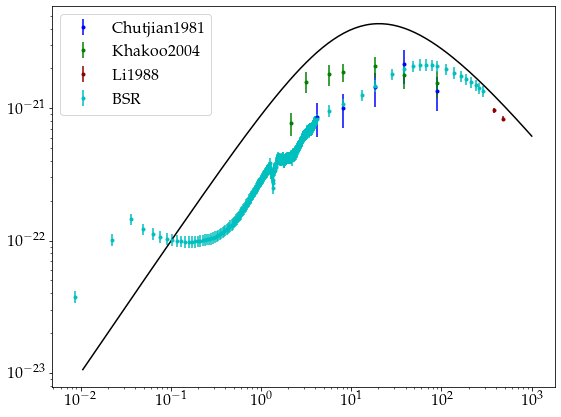

In [82]:
from models import *
level = 4
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0

targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if (refs[k]=='Tsurubuchi1996'):
        continue
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
    
theta_ref = np.array([2.54e-1,0.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_resonance_modified(4,theta_ref,Etest)
mask = model0 > 1.0e-23
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc="upper left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


[0.30520466 1.54496269]


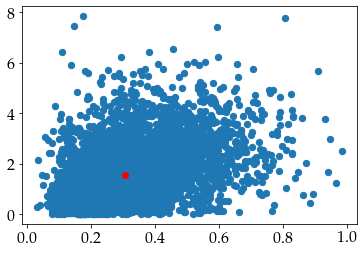

In [83]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s2.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

mean_1s2 = np.mean(flat_samples[:,:2], axis=0)
print(mean_1s2)

plt.figure(1)
plt.scatter(flat_samples[:,0], flat_samples[:,1],s=40.0)
plt.plot(mean_1s2[0], mean_1s2[1], 'or')

5984


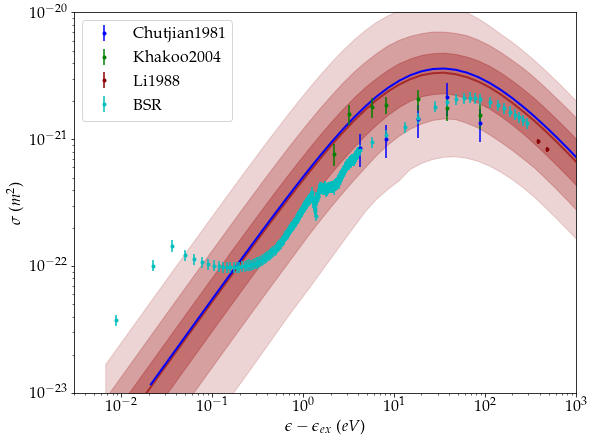

In [84]:
Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 50
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
    modelSamples[k] = Excite_resonance_modified(level,sample[:2],Etest)
#     mask = models > 1.0e-23
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest - E_ext[level-1], modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

nominal = Excite_resonance_modified(level,mean_1s2,Etest)
mask = nominal > 1.0e-23
plt.plot(Etest[mask]-E_ext[level-1], nominal[mask], "b-", linewidth=2.0)

for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s2.modified.curve1.pdf", dpi=1200)

filename = '../crs-Bayes-gpr/without-swarm/post-process/excitation.1s2.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

## Ionization

Rapp, D., & Englander-Golden, P. (1965). Total cross sections for lonization and attachment in gases by electron impact. I. Positive ionization. The Journal of Chemical Physics, 43(5), 1464–1479. https://doi.org/10.1063/1.1696957
1000.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
20.0
Straub, H. C., Renault, P., Lindsay, B. G., Smith, K. A., & Stebbings, R. F. (1995). Absolute partial and total cross sections for electron-impact ionization of argon from threshold to 1000 eV. Physical Review A, 52(2), 1115–1124. https://doi.org/10.1103/PhysRevA.52.1115
20.0
Wetzel, R. C., Baiocchi, F. A., Hayes, T. R., & Freund, R. S. (1987). Absolute cross sections for electron-impact ionization of the rare-gas atoms by the fast-neutral-beam method. Physical Review A, 35(2), 559

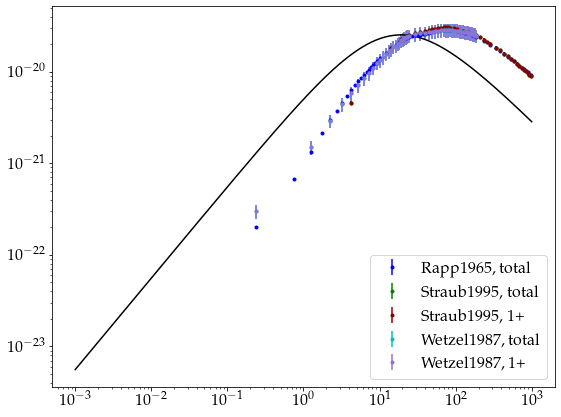

In [85]:
from models import *
level = 1
dataType1 = crs.typeDictS2I['Ionization, '+str(level)+'+']
dataType = crs.typeDictS2I['Ionization, total']
threshold = np.floor(10*E_ion[level-1])/10.0

targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]+', total']
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
    if dataType1 in swarm.datasets:
        targetrefs += [refs[k]+', 1+']
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
    
theta_ref = np.array([1.0, 1.0, 1.0])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ion[level-1]
model0 = total_Ion_BED(theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k>2): continue
    plt.errorbar(Wk[:,0]-E_ion[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ion[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./ionization.png',dpi=1200)

[ 4.47645771 -2.36374336 -3.44703479]


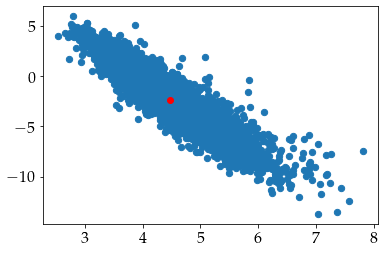

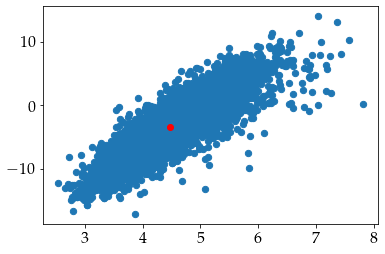

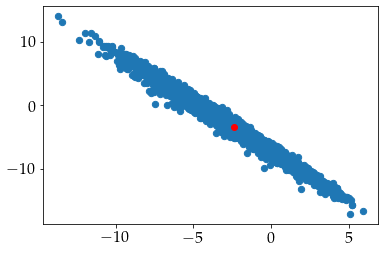

In [86]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.ionization.total.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/5), 5])

mean_ion = np.mean(flat_samples[:,:3], axis=0)
print(mean_ion)

idx = 1
for i in range(3):
    for j in range(i+1, 3):
        plt.figure(idx)
        plt.scatter(flat_samples[:,i], flat_samples[:,j],s=40.0)
        plt.plot(mean_ion[i], mean_ion[j], 'or')
        idx += 1

12832


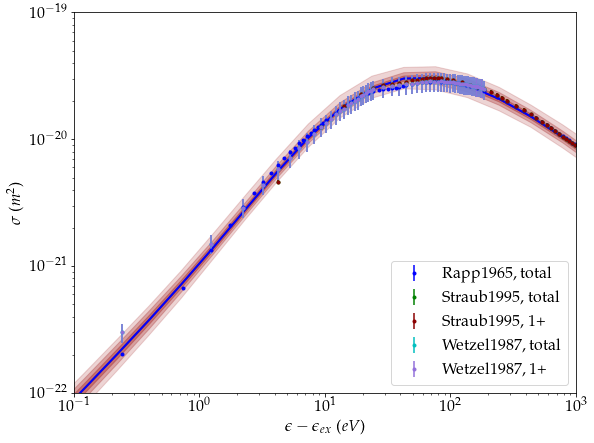

In [87]:
Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ion[level-1]
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
    modelSamples[k] = total_Ion_BED(sample[:3],Etest)
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ion[level-1], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest - E_ion[level-1], modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest - E_ion[level-1], modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest - E_ion[level-1], modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest - E_ion[level-1], modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

nominal = total_Ion_BED(mean_ion,Etest)
mask = nominal > 1.0e-25
plt.plot(Etest[mask]-E_ion[level-1], nominal[mask], "b-", linewidth=2.0)
    
for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ion[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-22, 1e-19])
plt.xlim([1e-1, 1e3])
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./ionization.total.curve.pdf", dpi=1200)

filename = '../crs-Bayes-gpr/without-swarm/post-process/ionization.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

## Elastic momentum

Mielewska, B., Linert, I., King, G. C., & Zubek, M. (2004). Differential cross sections for elastic electron scattering in argon over the angular range 130°-180°. Physical Review A - Atomic, Molecular, and Optical Physics, 69(6), 1–8. https://doi.org/10.1103/PhysRevA.69.062716
Panajotovic, R., et al. "Critical minima in elastic electron scattering by argon." Journal of Physics B: Atomic, Molecular and Optical Physics 30.24 (1997): 5877.
Gibson, J. C., Gulley, R. J., Sullivan, J. P., Buckman, S. J., Chan, V., & Burrow, P. D. (1996). Elastic electron scattering from argon at low incident energies. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(14), 3177–3195. https://doi.org/10.1088/0953-4075/29/14/025
Srivastava, S. K., Tanaka, H., Chutjian, A., & Trajmar, S. (1981). Elastic scattering of intermediate-energy electrons by Ar and Kr. Physical Review A, 23(5).


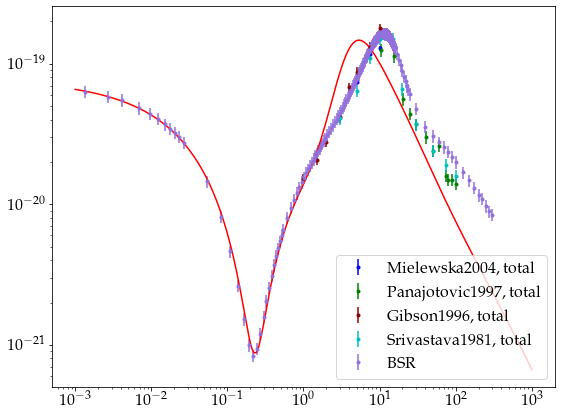

In [88]:
from models import *
dataType = crs.typeDictS2I['Elastic, momentum']


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]+', total']
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        W += [temp]
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==0)):
        targetrefs += ['BSR']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.1
        temp = np.append( temp, error, axis=1)
        W += [temp]
    
theta_ref = np.array([-1.488, 65.4, -84.3, 0.883])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest
model0 = elastic_MERT(theta_ref,Etest)
mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest,model0,'-r')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./elastic.pdf", dpi=600)
# plt.savefig('./elastic.png',dpi=1200)

[ -1.43321198  59.22342716 -73.25934028   1.02192592   0.53172813
   0.81122191   1.94126123]


/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_15319/3176973906.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(idx)


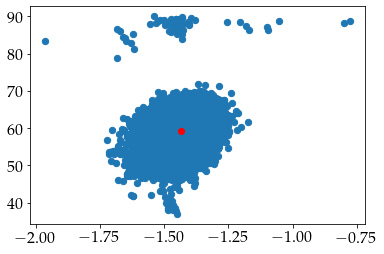

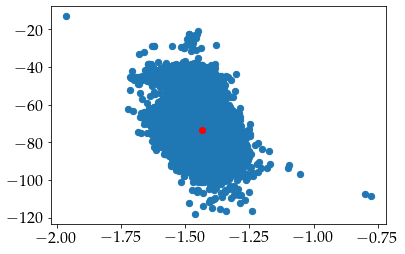

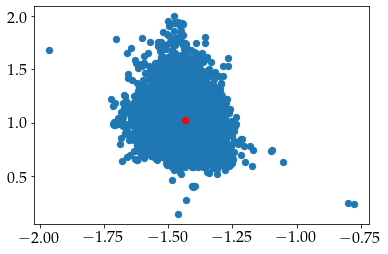

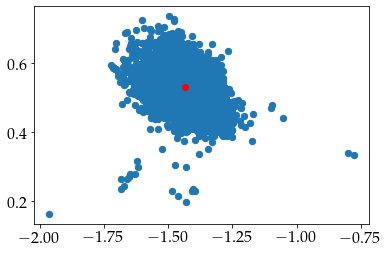

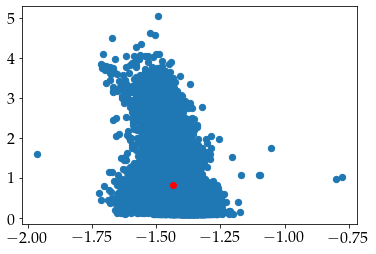

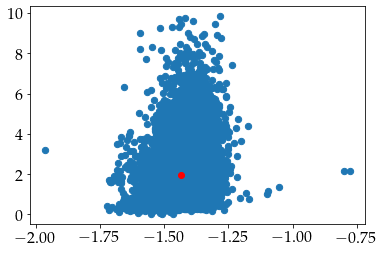

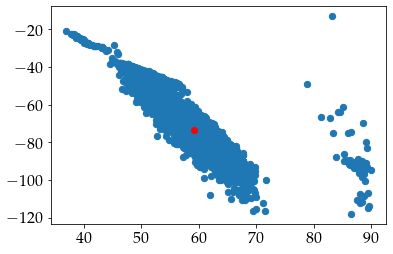

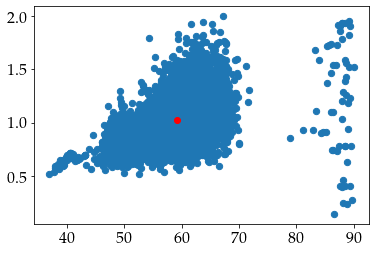

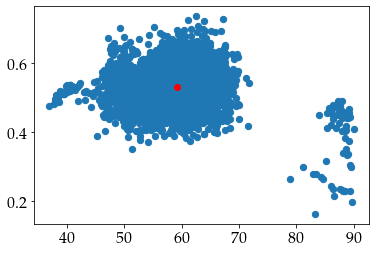

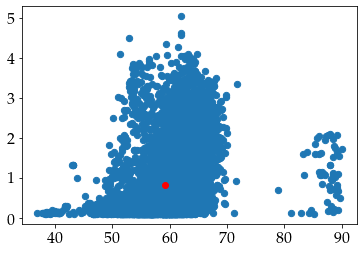

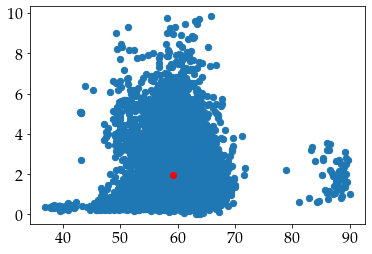

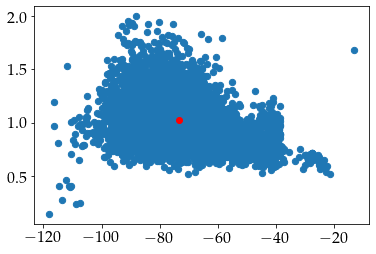

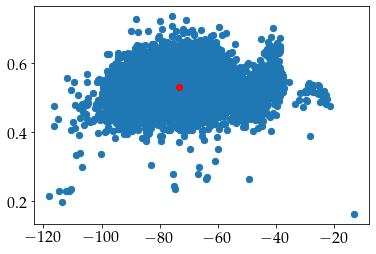

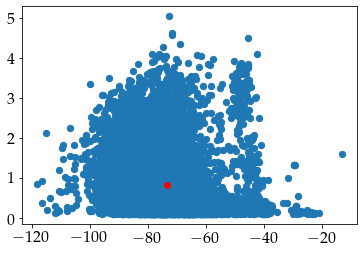

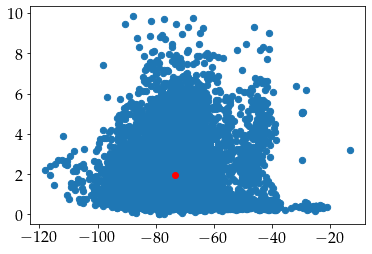

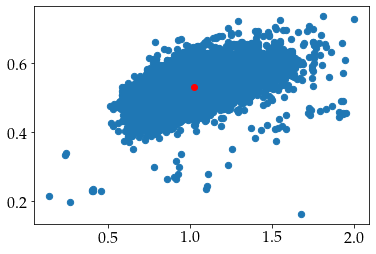

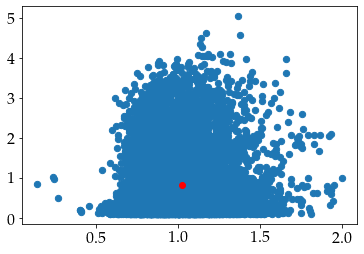

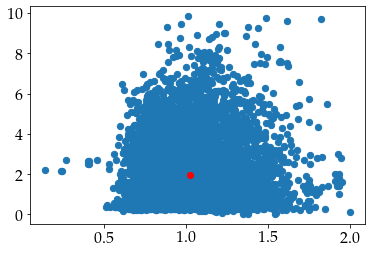

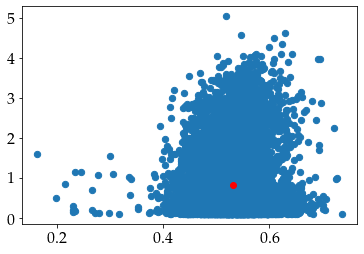

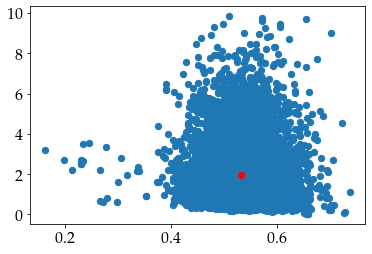

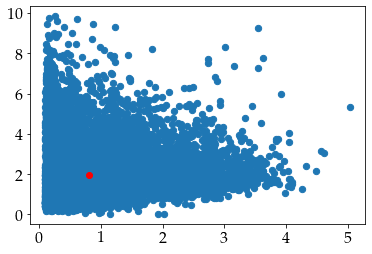

In [89]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.elastic.7param.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/9), 9])

mean_momentum = np.mean(flat_samples[:,:7], axis=0)
print(mean_momentum)

idx = 1
for i in range(7):
    for j in range(i+1, 7):
        plt.figure(idx)
        plt.scatter(flat_samples[:,i], flat_samples[:,j],s=40.0)
        plt.plot(mean_momentum[i], mean_momentum[j], 'or')
        idx += 1

8759


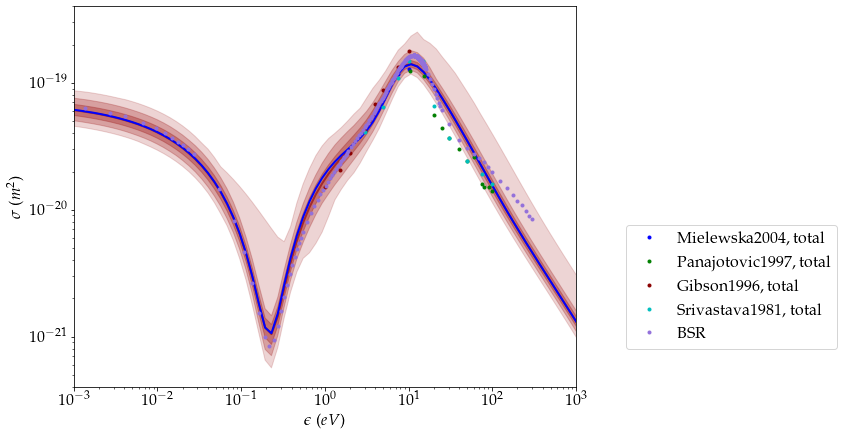

In [90]:
Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 150
wtest = np.linspace(-17,9.,Nw)
Etest = np.exp(wtest)
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
    modelSamples[k] = elastic_shifted_MERT(sample[:7],Etest)
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest, modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest, modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest, modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest, modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

nominal = elastic_shifted_MERT(mean_momentum,Etest)
mask = nominal > 1.0e-25
plt.plot(Etest[mask], nominal[mask], "b-", linewidth=2.0)
    
for k, Wk in enumerate(W):
    plt.plot(Wk[:,0],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([4e-22, 4e-19])
plt.xlim([1e-3, 1e3])
plt.legend(loc=(1.1,0.1))
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./elastic.curve.with-lxcats.pdf", dpi=1200)

filename = '../crs-Bayes-gpr/without-swarm/post-process/elastic.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

## Step-wise Ionization

4.211257479999999
Ton-That, D., & Flannery, M. R. (1977). Cross sections for ionization of metastable rare-gas atoms (Ne*, Ar*, Kr*, Xe*) and of metastable N2*, CO* molecules by electron impact. Physical Review A, 15(2), 517–526. https://doi.org/10.1103/PhysRevA.15.517
5.54764
4.2


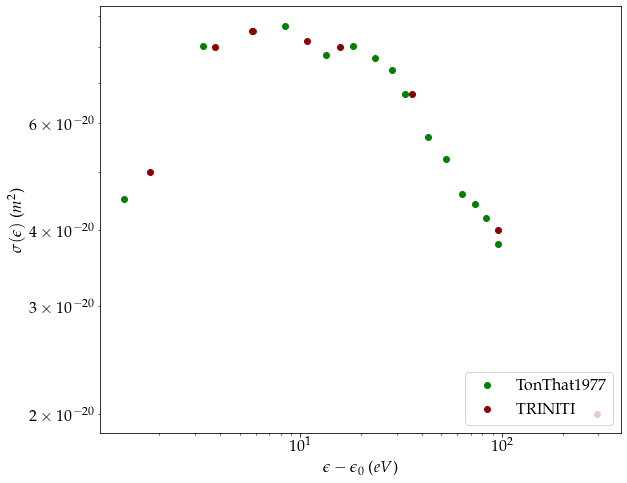

In [47]:
from models import *
dataType = crs.typeDictS2I['Step-wise Ionization, 1+']
deltaE = E_ion[0] - E_ext[0]
threshold = np.floor(10*deltaE)/10.0
print(deltaE)

targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        temp[:,2] = temp[:,1] * 0.18
        print(temp[0,0])
        W += [temp]
        
# Include TRINITI dataset, except the first entry (excitation level).
for c in TRINITI.crs:
    if ((c.colType==3) and (c.deltaE>=threshold) and (c.deltaE<=threshold+0.1)):
        targetrefs += ['TRINITI']
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.18
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        W += [temp]

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
theta_ref = np.array([-1, 10, 10])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + deltaE
model0 = total_Ion_BED(theta_ref,Etest, deltaE)
mask = model0 > 1.0e-25
# Etest = Etest[mask]
# model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     plt.errorbar(Wk[:,0]-deltaE,Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
    plt.loglog(Wk[:,0]-deltaE,Wk[:,1],'o',color=colors[k+1],label=targetrefs[k])
# plt.loglog(Etest - deltaE,model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon - \epsilon_0$ ($eV$)')
plt.ylabel('$\sigma(\epsilon)$ ($m^2$)')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower right")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.tight_layout()
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# fig.savefig('./step-wise.ionization.exp.pdf',dpi=1200)


[ 15.31447994 -27.77815293  34.27020331]


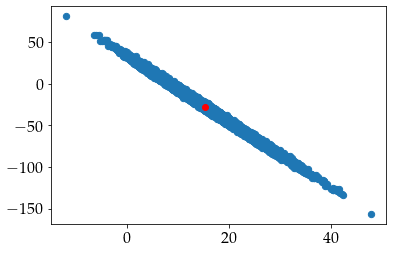

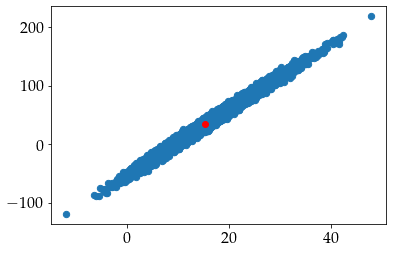

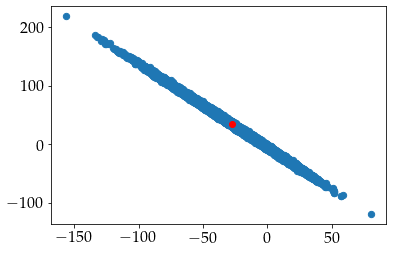

In [50]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.ionization.step-wise.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/3), 3])

mean_step_ion = np.mean(flat_samples[:,:3], axis=0)
print(mean_step_ion)

idx = 1
for i in range(3):
    for j in range(i+1, 3):
        plt.figure(idx)
        plt.scatter(flat_samples[:,i], flat_samples[:,j],s=40.0)
        plt.plot(mean_step_ion[i], mean_step_ion[j], 'or')
        idx += 1

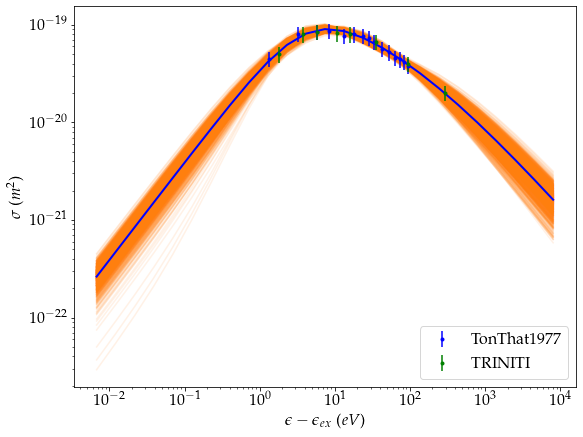

In [52]:
Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_step_ion[0]

inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    models = total_Ion_BED(sample[:3],Etest,E_step_ion[0])
    mask = models > 1.0e-25
    plt.plot(Etest[mask] - E_step_ion[0], models[mask], "C1", alpha=0.1)
    
nominal = total_Ion_BED(mean_step_ion,Etest,E_step_ion[0])
mask = nominal > 1.0e-25
plt.plot(Etest[mask]-E_step_ion[0], nominal[mask], "b-", linewidth=2.0)

for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0] - E_step_ion[0],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.legend(loc='lower right')
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./ionization.step-wise.curve.pdf", dpi=1200)

## Generate cross-section file

In [62]:
theta_ext = [mean_1s5, mean_1s4, mean_1s3, mean_1s2]
theta = [mean_momentum, mean_ion, theta_ext, mean_step_ion]
crsFilename = 'glow-discharge/nominal-crs/crs.nominal.Biagi.txt'
inputs = [theta, crsFilename]
print(inputs)

from forward_propagater import generateCrossSection
nominal_crs = generateCrossSection(inputs)

for c in nominal_crs.crs:
    c.printToScreen()

[[array([ -1.43321198,  59.22342716, -73.25934028,   1.02192592,
         0.53172813,   0.81122191,   1.94126123]), array([ 4.47645771, -2.36374336, -3.44703479]), [array([106.14268728,   2.13882303]), array([0.0801364, 0.9461873]), array([15.73364769,  1.96004018]), array([0.30520466, 1.54496269])], array([ 15.31447994, -27.77815293,  34.27020331])], 'glow-discharge/nominal-crs/crs.nominal.Biagi.txt']


## Nominal plasma condition for Bolsig

These nominal values are taken from Juan's glow discharge simulation.

In [2]:
Torr = 133.322    # Pa
p0 = 250e-3 * Torr
T0 = 300          # K
Te0 = 43000.      # K
qe = 1.60217663e-19 # C
kB = 1.380649e-23 # m2 kg s-2 K-1
ne0 = 5.0e15      # m-3
nex0 = 5.0e17     # m-3
nTotal0 = ne0 + (p0 - ne0 * kB * Te0) / kB / T0
ionDeg = ne0 / nTotal0 # approximated assuming small ionization degree
Xex0 = nex0 / nTotal0
print(nTotal0, ionDeg, Xex0)

bolsigCondition = [0., 0., 0., T0, T0,   \
                   0., ionDeg, ne0, 1.,   \
                   1., 1, 1, 2,              \
                   0., 200, 0, 200.,         \
                   1.0e-10, 1.0e-4, 10000, '%.5E %.5E' % (1. - Xex0, Xex0), 1]

8.046349292828951e+21 6.213998197239695e-07 6.213998197239696e-05


## Write an bolsig input file with a standard LXCat cross section dataset

In [73]:
from forward_propagater import writeInputFile
from input_writer import glowDischargeConfigs

config = glowDischargeConfigs['reaction300K'] # this is bolsig solver option configuration.
config['CONDITIONS'] = bolsigCondition

inputFile = 'glow-discharge/nominal-rxn/input.bolsig.dat'

outputFile = 'glow-discharge/nominal-rxn/output.bolsig.dat'
writeInputFile(inputFile, config, crsFilename, outputFile, noscreen=False)

In [74]:
import subprocess
command = "./bolsigminus %s" %(inputFile)

subprocess.check_call(command,shell=True)

READCOLLISIONS
 Ar
glow-discharge/nominal-crs/crs.nominal.Biagi.txt
 C1    Ar    Elastic                                             
 C2    Ar    Excitation    11.55 eV                              
 C3    Ar    Excitation    11.62 eV                              
 C4    Ar    Excitation    11.72 eV                              
 C5    Ar    Excitation    11.83 eV                              
 C6    Ar    Excitation    12.91 eV                              
 C7    Ar    Excitation    13.08 eV                              
 C8    Ar    Excitation    13.10 eV                              
 C9    Ar    Excitation    13.15 eV                              
 C10   Ar    Excitation    13.17 eV                              
 C11   Ar    Excitation    13.27 eV                              
 C12   Ar    Excitation    13.28 eV                              
 C13   Ar    Excitation    13.30 eV                              
 C14   Ar    Excitation    13.33 eV                              
 C15   A

R191  3814. Td    39.0 eV
R192  3915. Td    40.0 eV
R193  4017. Td    41.2 eV
R194  4120. Td    42.3 eV
R195  4226. Td    43.5 eV
R196  4332. Td    44.7 eV
R197  4441. Td    46.0 eV
R198  4551. Td    47.3 eV
R199  4662. Td    48.6 eV
R200  4775. Td    50.0 eV
SAVERESULTS
glow-discharge/nominal-rxn/output.bolsig.dat
FINISHED


0

## Read bolsig output

In [3]:
import numpy as np
from swarmParameters import bolsigOutput
outputFile = 'glow-discharge/nominal-rxn/output.bolsig.dat'
eV = qe / kB    # K

nominalOutput = bolsigOutput(outputFile)
Ue = nominalOutput.outputs[3].data[:,1]
Te = Ue / 1.5 * eV

for idx, table in nominalOutput.outputs.items():
    print('idx: %d, Label: %s, Type: %s, E: %.5E' % (idx, nominalOutput.typeDictI2S[idx], table.collisionType, table.deltaE))

label1s = ['C2','C3','C4','C5']
label2p = ['C%d' % k for k in range(6,16)]
labelIon = 'C46'
labelStepIon = 'C47'

## Reference reaction profiles
outputFilename = "./output/datasets/Biagi_v7.1+step.dat"
output = bolsigOutput(outputFilename)
Te0 = output.outputs[3].data[:,1] / 1.5 * eV
dataType = output.typeDictS2I['C2']
rateExcite0 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C6']
rateStepIon0 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps+step.dat"
output = bolsigOutput(outputFilename)
Te1 = output.outputs[3].data[:,1] / 1.5 * eV
dataType = output.typeDictS2I['C2']
rateExcite1 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C4']
rateStepIon1 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C3']
rateIon1 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps+step.nonzero_ion.dat"
output = bolsigOutput(outputFilename)
Te2 = output.outputs[3].data[:,1] / 1.5 * eV
dataType = output.typeDictS2I['C2']
rateExcite2 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C4']
rateStepIon2 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C3']
rateIon2 = output.outputs[dataType].data[:,1]

LiuStepIon = 2.05e-7 * np.exp(- 4.95 / (Te / eV)) * 1e-6

idx: 0, Label: Electric field / N (Td), Type: , E: 0.00000E+00
idx: 3, Label: Mean energy (eV), Type: , E: 0.00000E+00
idx: 4, Label: Mobility *N (1/m/V/s), Type: , E: 0.00000E+00
idx: 5, Label: Diffusion coefficient *N (1/m/s), Type: , E: 0.00000E+00
idx: 6, Label: Energy mobility *N (1/m/V/s), Type: , E: 0.00000E+00
idx: 7, Label: Energy diffusion coef. D*N (1/m/s), Type: , E: 0.00000E+00
idx: 8, Label: Total collision freq. /N (m3/s), Type: , E: 0.00000E+00
idx: 9, Label: Momentum frequency /N (m3/s), Type: , E: 0.00000E+00
idx: 22, Label: e-i momentum frequency /N (m3/s), Type: , E: 0.00000E+00
idx: 10, Label: Total ionization freq. /N (m3/s), Type: , E: 0.00000E+00
idx: 11, Label: Townsend ioniz. coef. alpha/N (m2), Type: , E: 0.00000E+00
idx: 12, Label: Power /N (eV m3/s), Type: , E: 0.00000E+00
idx: 13, Label: Elastic power loss /N (eV m3/s), Type: , E: 0.00000E+00
idx: 14, Label: Inelastic power loss /N (eV m3/s), Type: , E: 0.00000E+00
idx: 15, Label: Growth power /N (eV m3/s)

## Reactions for 4-species mechanism

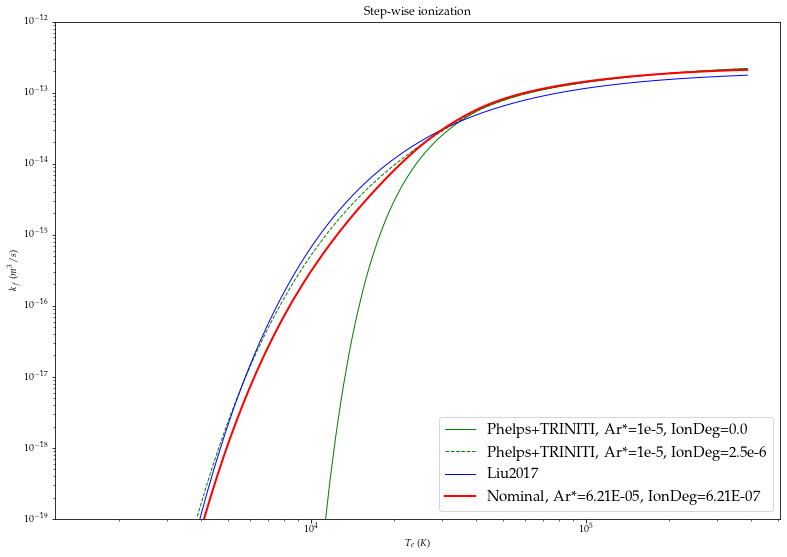

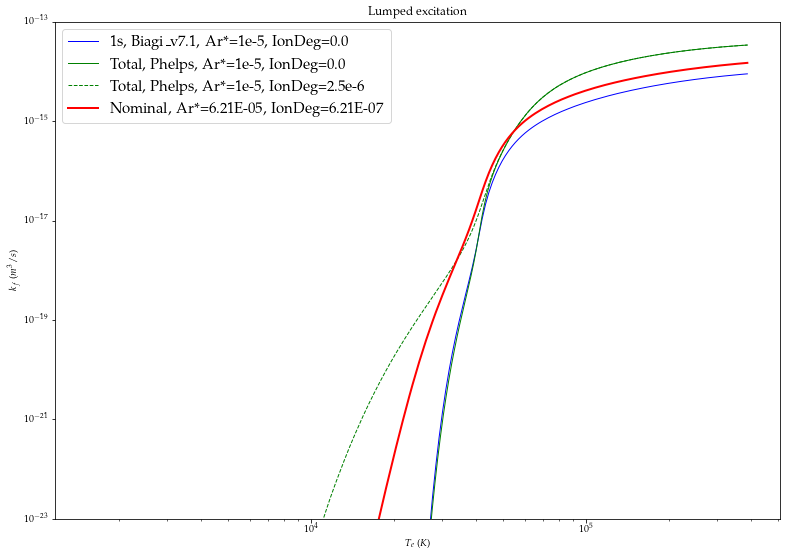

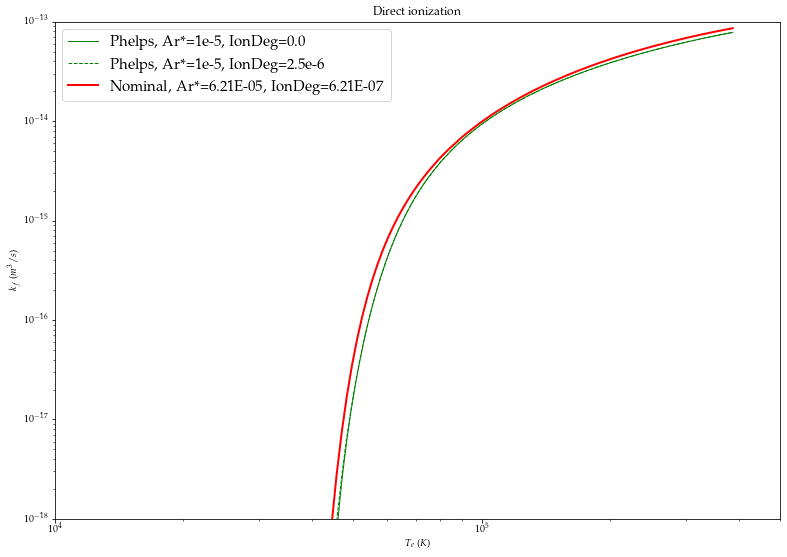

In [15]:
directory = 'glow-discharge/nominal-rxn/4species'

rateIon = nominalOutput.outputs[nominalOutput.typeDictS2I[labelIon]].data[:,1]
rateStepIon = nominalOutput.outputs[nominalOutput.typeDictS2I[labelStepIon]].data[:,1]

rateExcite = np.zeros(rateIon.size)
for label in label1s:
    rateExcite += nominalOutput.outputs[nominalOutput.typeDictS2I[label]].data[:,1]

plt.figure(1)
plt.loglog(Te1, rateStepIon1,'-', color='g', linewidth=1.0, label='Phelps+TRINITI, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateStepIon2,'--', color='g', linewidth=1.0, label='Phelps+TRINITI, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Te, LiuStepIon,'-', color='b', linewidth=1.0, label='Liu2017')
plt.loglog(Te, rateStepIon,'-', color='r', linewidth=2.0, label='Nominal, Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.title('Step-wise ionization')
plt.xlabel('$T_e$ ($K$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.ylim([1e-19, 1e-12])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(12, 9)
plt.legend(loc='lower right', prop={'size': 15})
# fig.savefig("%s/step_ionization.pdf" % directory, dpi=1200)
    
plt.figure(2)
plt.loglog(Te0, rateExcite0,'-', color='b', linewidth=1.0, label='1s, Biagi_v7.1, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te1, rateExcite1,'-', color='g', linewidth=1.0, label='Total, Phelps, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateExcite2,'--', color='g', linewidth=1.0, label='Total, Phelps, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Te, rateExcite,'-', color='r', linewidth=2.0, label='Nominal, Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.title('Lumped excitation')
plt.xlabel('$T_e$ ($K$)')
plt.ylabel('$k_f$ ($m^3/s$)')
# plt.xlim([0.5, 30])
plt.ylim([1e-23, 1e-13])
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(12, 9)
# fig.savefig("%s/lumped_excitation.pdf" % directory, dpi=1200)

plt.figure(3)
plt.loglog(Te1, rateIon1,'-', color='g', linewidth=1.0, label='Phelps, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateIon2,'--', color='g', linewidth=1.0, label='Phelps, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Te, rateIon,'-', color='r', linewidth=2.0, label='Nominal, Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.title('Direct ionization')
plt.xlabel('$T_e$ ($K$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.xlim([1e4, 5e5])
plt.ylim([1e-18, 1e-13])
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(12, 9)
# fig.savefig("%s/ionization.pdf" % directory, dpi=1200)

# temp = np.append(Te[...,None], rateExcite[...,None], axis=1)
# filename = '%s/lumped_1s.excite.txt' % directory
# np.savetxt(filename, temp)
# temp = np.append(Te[...,None], rateIon[...,None], axis=1)
# filename = '%s/ionization.txt' % directory
# np.savetxt(filename, temp)
# temp = np.append(Te[...,None], rateStepIon[...,None], axis=1)
# filename = '%s/step_ionization.txt' % directory
# np.savetxt(filename, temp)
comments = 'This is nominal reaction rate for 4-species mechanism in glow-discharge configuration, computed from bolsig with nominal cross section sample.'

import h5py
NA = 6.0221408e+23
temp = np.append(Te[...,None], rateExcite[...,None] * NA, axis=1)
filename = '%s/lumped_1s.excite.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments
    
temp = np.append(Te[...,None], rateIon[...,None] * NA, axis=1)
filename = '%s/ionization.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments
    
temp = np.append(Te[...,None], rateStepIon[...,None] * NA, axis=1)
filename = '%s/step_ionization.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments

## Reactions for 6-species mechanism

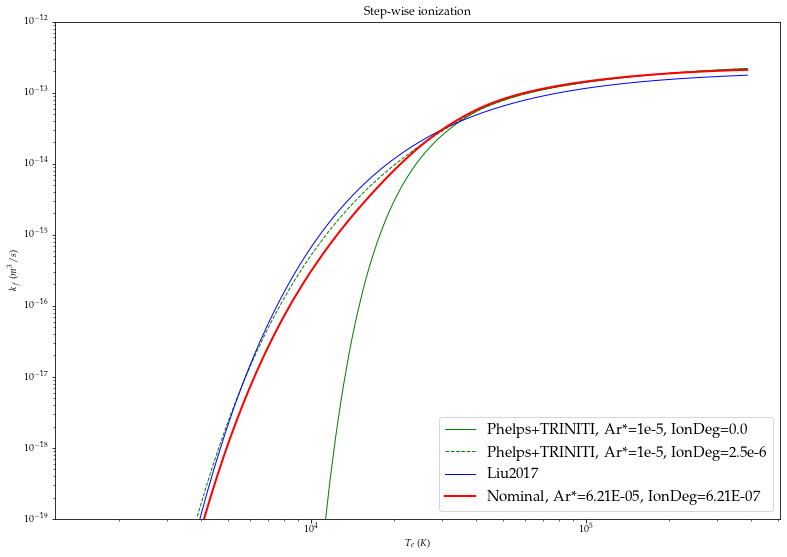

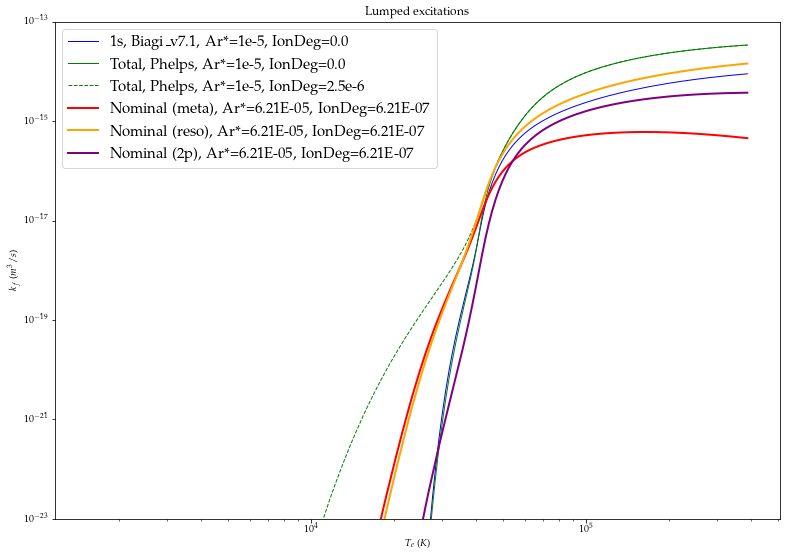

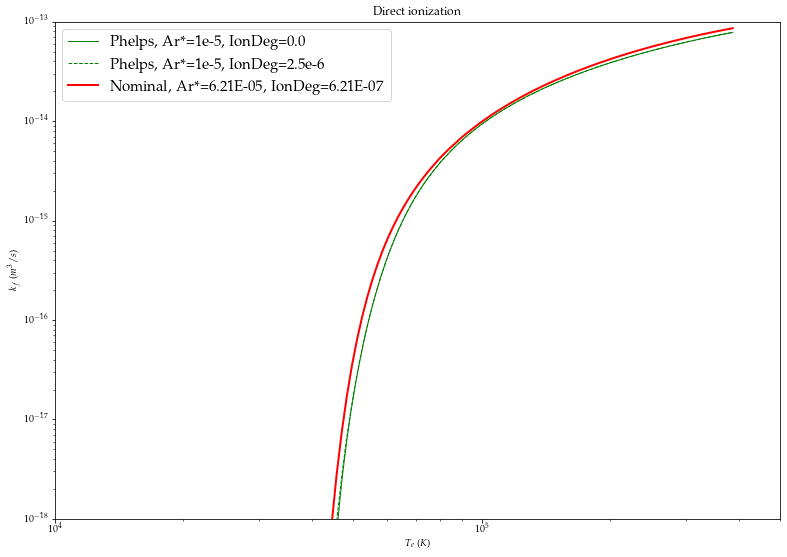

In [14]:
directory = 'glow-discharge/nominal-rxn/6species'

rateIon = nominalOutput.outputs[nominalOutput.typeDictS2I[labelIon]].data[:,1]
rateStepIon = nominalOutput.outputs[nominalOutput.typeDictS2I[labelStepIon]].data[:,1]

rateMetastable = np.zeros(rateIon.size)
label1s5 = label1s[0]
label1s3 = label1s[2]
rateMetastable += nominalOutput.outputs[nominalOutput.typeDictS2I[label1s5]].data[:,1]
rateMetastable += nominalOutput.outputs[nominalOutput.typeDictS2I[label1s3]].data[:,1]

rateResonance = np.zeros(rateIon.size)
label1s4 = label1s[1]
label1s2 = label1s[3]
rateResonance += nominalOutput.outputs[nominalOutput.typeDictS2I[label1s4]].data[:,1]
rateResonance += nominalOutput.outputs[nominalOutput.typeDictS2I[label1s2]].data[:,1]

rate2p = np.zeros(rateIon.size)
for label in label2p:
    rate2p += nominalOutput.outputs[nominalOutput.typeDictS2I[label]].data[:,1]

plt.figure(1)
plt.loglog(Te1, rateStepIon1,'-', color='g', linewidth=1.0, label='Phelps+TRINITI, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateStepIon2,'--', color='g', linewidth=1.0, label='Phelps+TRINITI, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Te, LiuStepIon,'-', color='b', linewidth=1.0, label='Liu2017')
plt.loglog(Te, rateStepIon,'-', color='r', linewidth=2.0, label='Nominal, Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.title('Step-wise ionization')
plt.xlabel('$T_e$ ($K$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.ylim([1e-19, 1e-12])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(12, 9)
plt.legend(loc='lower right', prop={'size': 15})
fig.savefig("%s/step_ionization.pdf" % directory, dpi=1200)
    
plt.figure(2)
plt.loglog(Te0, rateExcite0,'-', color='b', linewidth=1.0, label='1s, Biagi_v7.1, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te1, rateExcite1,'-', color='g', linewidth=1.0, label='Total, Phelps, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateExcite2,'--', color='g', linewidth=1.0, label='Total, Phelps, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Te, rateMetastable,'-', color='r', linewidth=2.0, label='Nominal (meta), Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.loglog(Te, rateResonance,'-', color='orange', linewidth=2.0, label='Nominal (reso), Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.loglog(Te, rate2p,'-', color='purple', linewidth=2.0, label='Nominal (2p), Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.title('Lumped excitations')
plt.xlabel('$T_e$ ($K$)')
plt.ylabel('$k_f$ ($m^3/s$)')
# plt.xlim([0.5, 30])
plt.ylim([1e-23, 1e-13])
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(12, 9)
fig.savefig("%s/excitations.pdf" % directory, dpi=1200)

plt.figure(3)
plt.loglog(Te1, rateIon1,'-', color='g', linewidth=1.0, label='Phelps, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateIon2,'--', color='g', linewidth=1.0, label='Phelps, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Te, rateIon,'-', color='r', linewidth=2.0, label='Nominal, Ar*=%.2E, IonDeg=%.2E' % (Xex0, ionDeg))
plt.title('Direct ionization')
plt.xlabel('$T_e$ ($K$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.xlim([1e4, 5e5])
plt.ylim([1e-18, 1e-13])
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(12, 9)
fig.savefig("%s/ionization.pdf" % directory, dpi=1200)

# temp = np.append(Te[...,None], rateMetastable[...,None], axis=1)
# filename = '%s/lumped.metastable.txt' % directory
# np.savetxt(filename, temp)
# temp = np.append(Te[...,None], rateResonance[...,None], axis=1)
# filename = '%s/lumped.resonance.txt' % directory
# np.savetxt(filename, temp)
# temp = np.append(Te[...,None], rate2p[...,None], axis=1)
# filename = '%s/lumped.2p.txt' % directory
# np.savetxt(filename, temp)
# temp = np.append(Te[...,None], rateIon[...,None], axis=1)
# filename = '%s/ionization.txt' % directory
# np.savetxt(filename, temp)
# temp = np.append(Te[...,None], rateStepIon[...,None], axis=1)
# filename = '%s/step_ionization.txt' % directory
# np.savetxt(filename, temp)
comments = 'This is nominal reaction rate for 6-species mechanism in glow-discharge configuration, computed from bolsig with nominal cross section sample.'

import h5py
NA = 6.0221408e+23
temp = np.append(Te[...,None], rateMetastable[...,None] * NA, axis=1)
filename = '%s/lumped.metastable.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments

temp = np.append(Te[...,None], rateResonance[...,None] * NA, axis=1)
filename = '%s/lumped.resonance.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments
    
temp = np.append(Te[...,None], rate2p[...,None] * NA, axis=1)
filename = '%s/lumped.2p.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments
    
temp = np.append(Te[...,None], rateIon[...,None] * NA, axis=1)
filename = '%s/ionization.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments

temp = np.append(Te[...,None], rateStepIon[...,None] * NA, axis=1)
filename = '%s/step_ionization.h5' % directory
with h5py.File(filename, 'w') as f:
    dset = f.create_dataset("table", temp.shape, data=temp)
    dset.attrs['name0'] = 'electron temperature'
    dset.attrs['unit0'] = 'K'
    dset.attrs['name1'] = 'reaction rate'
    dset.attrs['unit1'] = 'm3/mol/s'
    dset.attrs['comments'] = comments

Text(0, 0.5, 'Equilibrium constant')

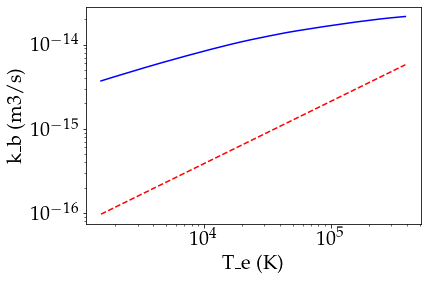

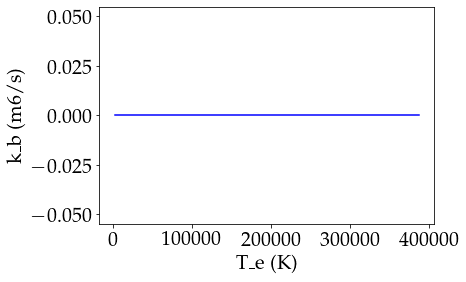

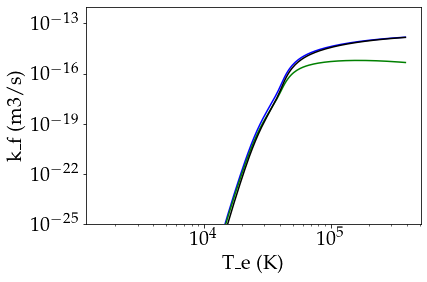

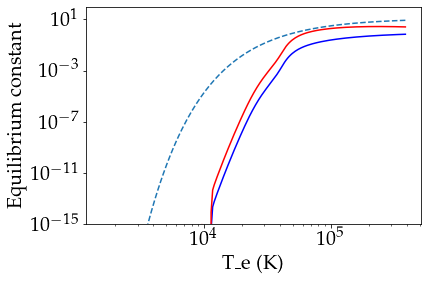

In [29]:
outputFile = 'glow-discharge/nominal-rxn/output.bolsig.reverse.dat'
reverseOutput = bolsigOutput(outputFile)

reverseRateIon = reverseOutput.outputs[reverseOutput.typeDictS2I[labelIon]].data[:,1]
reverseRateStepIon = reverseOutput.outputs[reverseOutput.typeDictS2I[labelStepIon]].data[:,1]

reverseRateExcite = np.zeros(rateIon.size)
for label in label1s:
    reverseRateExcite += reverseOutput.outputs[reverseOutput.typeDictS2I[label]].data[:,1]
    
reverseRateMetastable = np.zeros(rateIon.size)
reverseRateMetastable += reverseOutput.outputs[reverseOutput.typeDictS2I[label1s5]].data[:,1]
reverseRateMetastable += reverseOutput.outputs[reverseOutput.typeDictS2I[label1s3]].data[:,1]

reverseRateResonance = np.zeros(rateIon.size)
reverseRateResonance += reverseOutput.outputs[reverseOutput.typeDictS2I[label1s4]].data[:,1]
reverseRateResonance += reverseOutput.outputs[reverseOutput.typeDictS2I[label1s2]].data[:,1]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 20,
})

plt.figure(1)
plt.loglog(Te, reverseRateExcite, '-b')
# plt.loglog(Te, reverseRateMetastable, '-g')
# plt.loglog(Te, reverseRateResonance, '-',color='k')
plt.loglog(Te, 4.30e-16 * (Ue / 1.5) ** 0.74, '--r')
plt.xlabel('T_e (K)')
plt.ylabel('k_b (m3/s)')

plt.figure(2)
plt.plot(Te, reverseRateIon, '-b')
# plt.loglog(Te, 5.0e-27 * (Ue / 1.5) ** (-4.5), '--r')
plt.xlabel('T_e (K)')
plt.ylabel('k_b (m6/s)')

plt.figure(3)
plt.loglog(Te, rateExcite, '-b')
plt.loglog(Te, rateMetastable, '-g')
plt.loglog(Te, rateResonance, '-',color='k')
plt.ylim([1e-25, 1e-12])
plt.xlabel('T_e (K)')
plt.ylabel('k_f (m3/s)')

g0, g1 = 1, 12
e1 = 11.55
plt.figure(4)
plt.loglog(Te, rateExcite / reverseRateExcite, '-b')
plt.loglog(Te, rateExcite / (4.30e-16 * (Ue / 1.5) ** 0.74), '-r')
plt.loglog(Te, g1 / g0 * np.exp(- e1 / (Ue / 1.5)), '--')
plt.ylim([1e-15, 1e2])
plt.xlabel('T_e (K)')
plt.ylabel('Equilibrium constant')

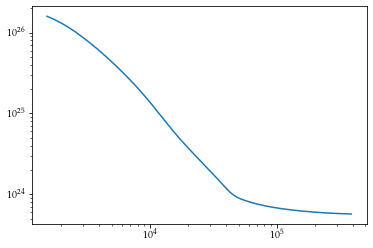

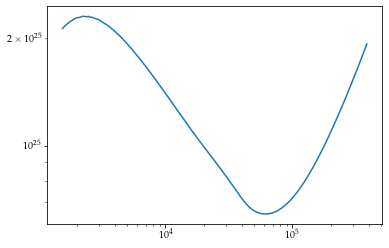

In [5]:
# nominalOutput = bolsigOutput(outputFile)
mobility = nominalOutput.outputs[4].data[:,1]
diffusion = nominalOutput.outputs[5].data[:,1]

plt.figure(1)
plt.loglog(Te, mobility)

plt.figure(2)
plt.loglog(Te, diffusion)

import h5py
filename = "glow-discharge/nominal-rxn/nominal_transport.h5"
with h5py.File(filename,'w') as f:
    f.attrs['comment'] = 'Mobility/diffusion coefficient from nominal cross sections, evaluated by BOLSIG.'
    data = np.array([Te, mobility]).T
    dset = f.create_dataset('mobility', data=data)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Mobility * N'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = '1/m/V/s'
    
    data = np.array([Te, diffusion]).T
    dset = f.create_dataset('diffusivity', data=data)
    dset.attrs['name0'] = 'Electron Temperature'
    dset.attrs['name1'] = 'Diffusivity * N'
    dset.attrs['unit0'] = 'K'
    dset.attrs['unit1'] = '1/m/s'